# Training a ML Model to Predict Drowsiness

The original approach represents each sample using around 7,000 features, corresponding to the temporal evolution of 8 signals over 875 consecutive time steps. While this preserves a large amount of information, it also results in a very high-dimensional feature space.

This enhanced approach will instead extract descriptive features from the temporal evolution of each signal. Rather than providing the Random Forest with all 875 consecutive values, we will summarize the behavior of each signal using statistical and temporal characteristics such as the mean, standard deviation, minimum and maximum values, peaks, and other relevant features.

This allows us to reduce the representation from roughly 7,000 raw features to around 20–30 meaningful features that describe the temporal behavior of the 8 signals for each individual.

The objective is therefore not simply to reduce the number of features, but to provide the Random Forest with a more meaningful representation of the underlying patterns in the data. Using raw values for each individual time step may lead the decision trees within the Random Forest to rely on very specific temporal positions. For example, a model could learn a rule based on whether a person's eyes are closed at a particular frame, even though the exact position of that frame is not intrinsically meaningful for determining drowsiness.

By extracting features that characterize the overall temporal behavior of the signals, we aim to make the model rely on more generalizable patterns rather than on specific time-step values.

## Get the data

In [105]:
import pandas as pd

data = pd.read_csv("csv/signes.csv")

data.head()

,video_name,EAR_left_0,EAR_right_0,EAR_mean_0,MAR_0,EBR_0,PERCLOS_0,HOP_gd_0,HOP_hb_0,EAR_left_1,...,HOP_hb_873,EAR_left_874,EAR_right_874,EAR_mean_874,MAR_874,EBR_874,PERCLOS_874,HOP_gd_874,HOP_hb_874,class
0,kss#1-3#F#rldd#17-0.mp4_1.mp4,0.368546,0.371066,0.369806,0.003794,0,0.0,89.996526,4.465502,0.378372,...,3.538908,0.366793,0.366085,0.366439,0.003091,0,8.000000,89.994856,3.620867,0
1,kss#1-3#F#rldd#21-0.mp4_1.mp4,0.315517,0.281914,0.298715,0.006160,0,0.0,90.012625,2.051549,0.314886,...,5.143141,0.345992,0.292497,0.319244,0.007726,0,2.400000,90.015657,5.207324,0
2,kss#1-3#F#rldd#57-0.mp4_5.mp4,0.312824,0.290006,0.301415,0.003691,0,0.0,90.021010,5.515728,0.321846,...,4.564574,0.286394,0.249781,0.268087,0.006888,1,4.800000,90.026613,4.552479,0
3,kss#1-3#F#rldd#59-0.mp4_4.mp4,0.331562,0.346838,0.339200,0.003254,0,0.0,89.986877,1.336402,0.341735,...,0.507546,0.348462,0.353522,0.350992,0.003047,0,13.714286,89.994275,0.511410,0
4,kss#8-9#F#rldd#12-10.mp4_3.mp4,0.318018,0.338801,0.328409,0.009697,0,0.0,89.974311,4.051703,0.320297,...,2.222282,0.122808,0.119565,0.121187,0.009761,1,21.714286,89.975156,2.369169,2


## Prepare the data

### Regroup videos

In [106]:
data["video_name"] = data["video_name"].str.split("_").str[0]
data.head()

,video_name,EAR_left_0,EAR_right_0,EAR_mean_0,MAR_0,EBR_0,PERCLOS_0,HOP_gd_0,HOP_hb_0,EAR_left_1,...,HOP_hb_873,EAR_left_874,EAR_right_874,EAR_mean_874,MAR_874,EBR_874,PERCLOS_874,HOP_gd_874,HOP_hb_874,class
0,kss#1-3#F#rldd#17-0.mp4,0.368546,0.371066,0.369806,0.003794,0,0.0,89.996526,4.465502,0.378372,...,3.538908,0.366793,0.366085,0.366439,0.003091,0,8.000000,89.994856,3.620867,0
1,kss#1-3#F#rldd#21-0.mp4,0.315517,0.281914,0.298715,0.006160,0,0.0,90.012625,2.051549,0.314886,...,5.143141,0.345992,0.292497,0.319244,0.007726,0,2.400000,90.015657,5.207324,0
2,kss#1-3#F#rldd#57-0.mp4,0.312824,0.290006,0.301415,0.003691,0,0.0,90.021010,5.515728,0.321846,...,4.564574,0.286394,0.249781,0.268087,0.006888,1,4.800000,90.026613,4.552479,0
3,kss#1-3#F#rldd#59-0.mp4,0.331562,0.346838,0.339200,0.003254,0,0.0,89.986877,1.336402,0.341735,...,0.507546,0.348462,0.353522,0.350992,0.003047,0,13.714286,89.994275,0.511410,0
4,kss#8-9#F#rldd#12-10.mp4,0.318018,0.338801,0.328409,0.009697,0,0.0,89.974311,4.051703,0.320297,...,2.222282,0.122808,0.119565,0.121187,0.009761,1,21.714286,89.975156,2.369169,2


In [107]:
data["video_name"].value_counts()

video_name
kss#6-7#L#rldd#26-5.mp4     25
kss#8-9#F#rldd#49-10        25
kss#8-9#F#rldd#24-10.mp4    22
kss#1-3#F#rldd#24-0.mp4     21
kss#1-3#F#rldd#03-0.mp4     19
                            ..
kss#1-3#F#rldd#30-0.mp4      1
kss#8-9#F#rldd#03-10.mp4     1
kss#1-3#F#rldd#02-0.mp4      1
kss#6-7#F#rldd#11-5.mp4      1
kss#8-9#F#rldd#21-10.mp4     1
Name: count, Length: 129, dtype: int64

On voit que les instances sont des extrait de video mais que la proportion n'est homogene pour chaque video, on retrouve 25 extrait pour certaines videos et 1 pour d'autres, donc on doit faire attention a bien diviser le jeu de donnée. ON doit faire en sorte de split par video et de garder les classes equilibrées.

### Replacing EBR and PERCLOS

EBR and PERCLOS are not always reliable because EBR counts blinks using an adaptive threshold, while PERCLOS is directly based on this blink/open-closed classification.

The main issue with this approach is that the decision is made frame by frame using a threshold. There is no real notion of continuity or confidence between frames. A small amount of noise can therefore be enough to trigger a false blink, and the threshold may not work equally well for every subject.

Since PERCLOS is calculated from the same open/closed classification, it is also affected by these limitations.

#### Hidden Markov Models

A **Markov model** describes a system that evolves between different states over time. The main idea is that the probability of the next state only depends on the current state.

For example, an eye can be either **open** or **closed**. The next state mainly depends on the current state.

A **Hidden Markov Model (HMM)** extends this idea by considering that the actual states are **hidden** and cannot be observed directly.

The model is represented by a pair $(X_n, Y_n)$:

* **$X_n$** is the hidden state, representing the actual state of the eye (**open** or **closed**).
* **$Y_n$** is the observation, representing the information we can measure from the eye, such as an image or extracted features.

The goal is therefore to use the observations $Y_n$ to infer the most likely sequence of hidden states $X_n$.

Instead of using a fixed threshold for each frame, the HMM learns the transition and observation patterns directly from the data. It can then use the whole sequence of observations to determine whether the eye is open or closed. This makes the classification less sensitive to noise and better adapted to each subject, without having to manually choose an arbitrary threshold.

In [108]:
# Drop previous misfunctionning data
columns_to_drop = [
    f"{prefix}_{i}"
    for prefix in ["EBR", "PERCLOS"]
    for i in range(875)
]

data = data.drop(columns=columns_to_drop)

In [109]:
# Data to try our HMM on
X_0 = data[data["video_name"]=="kss#1-3#F#rldd#27-0.mp4"]

ear_mean_cols = [c for c in X_0.columns if c.startswith("EAR_mean_")]

X_ear_mean_0 = X_0[ear_mean_cols].values.flatten()  # bout à bout, ligne par ligne dans l'ordre du dataframe
X_ear_mean_0 = X_ear_mean_0.reshape(-1, 1)  # forme (n_frames_total, 1), obligatoire pour hmmlearn

X_1 = data[data["video_name"]=="kss#6-7#L#rldd#26-5.mp4"]

ear_mean_cols = [c for c in X_1.columns if c.startswith("EAR_mean_")]

X_ear_mean_1 = X_1[ear_mean_cols].values.flatten()  # bout à bout, ligne par ligne dans l'ordre du dataframe
X_ear_mean_1 = X_ear_mean_1.reshape(-1, 1)  # forme (n_frames_total, 1), obligatoire pour hmmlearn

X_2 = data[data["video_name"]=="kss#8-9#F#rldd#24-10.mp4"]

ear_mean_cols = [c for c in X_2.columns if c.startswith("EAR_mean_")]

X_ear_mean_2 = X_2[ear_mean_cols].values.flatten()  # bout à bout, ligne par ligne dans l'ordre du dataframe
X_ear_mean_2 = X_ear_mean_2.reshape(-1, 1)  # forme (n_frames_total, 1), obligatoire pour hmmlearn

In [110]:
from hmmlearn import hmm
import numpy as np


sequences = {
    "sujet_0": X_ear_mean_0,
    "sujet_1": X_ear_mean_1,
    "sujet_2": X_ear_mean_2,
}

n_values = [2, 3, 4, 6, 8, 10]
results = {name: {} for name in sequences}

for name, seq in sequences.items():
    print(f"--- {name} ({len(seq)} frames) ---")
    for n in n_values:
        m = hmm.GaussianHMM(n_components=n, covariance_type="diag", n_iter=200, random_state=42)
        m.fit(seq)
        logL = m.score(seq)
        n_params = n*n + 2*n - 1
        bic = -2*logL + n_params*np.log(len(seq))

        # Écart-type de l'état le plus bas
        closed_state = np.argmin(m.means_.flatten())
        closed_std = np.sqrt(m.covars_[closed_state]).flatten()[0]

        results[name][n] = {"bic": bic, "closed_std": closed_std}
        print(f"  n={n}: BIC={bic:.1f}, std(closed state)={closed_std:.3f}")

    best_n = min(results[name], key=lambda n: results[name][n]["bic"])
    print(f"  -> n optimal (BIC min) pour {name} : {best_n}\n")

# Nombre d'états optimal en agrégeant les 3 sujets
overall_best = {}
for n in n_values:
    overall_best[n] = np.mean([results[name][n]["bic"] for name in sequences])

n_optimal = min(overall_best, key=overall_best.get)
print("BIC moyen par n :", {n: round(v, 1) for n, v in overall_best.items()})
print(f"\n=> n optimal global (minimal mean BIC score for 3 classes) : {n_optimal}")

--- sujet_0 (15750 frames) ---
  n=2: BIC=-77068.6, std(closed state)=0.035
  n=3: BIC=-90396.3, std(closed state)=0.076
  n=4: BIC=-98068.0, std(closed state)=0.080
  n=6: BIC=-104087.7, std(closed state)=0.078
  n=8: BIC=-107502.2, std(closed state)=31.623


Model is not converging.  Current: 55349.99951350275 is not greater than 55350.020045524885. Delta is -0.02053202213573968


  n=10: BIC=-109550.0, std(closed state)=0.079
  -> n optimal (BIC min) pour sujet_0 : 10

--- sujet_1 (21875 frames) ---
  n=2: BIC=-62707.5, std(closed state)=0.102
  n=3: BIC=-70808.7, std(closed state)=0.139
  n=4: BIC=-97738.2, std(closed state)=0.103
  n=6: BIC=-105047.6, std(closed state)=0.103


Model is not converging.  Current: 57250.07853980456 is not greater than 57250.11417546361. Delta is -0.03563565904914867


  n=8: BIC=-113710.6, std(closed state)=0.099
  n=10: BIC=-116163.7, std(closed state)=0.033
  -> n optimal (BIC min) pour sujet_1 : 10

--- sujet_2 (19250 frames) ---
  n=2: BIC=-73160.7, std(closed state)=0.055
  n=3: BIC=-73117.2, std(closed state)=0.054
  n=4: BIC=-91575.3, std(closed state)=0.050
  n=6: BIC=-96778.6, std(closed state)=0.028
  n=8: BIC=-103859.5, std(closed state)=0.022


Model is not converging.  Current: 51344.83398028593 is not greater than 51344.834845267054. Delta is -0.0008649811279610731


  n=10: BIC=-101515.6, std(closed state)=0.027
  -> n optimal (BIC min) pour sujet_2 : 8

BIC moyen par n : {2: np.float64(-70978.9), 3: np.float64(-78107.4), 4: np.float64(-95793.8), 6: np.float64(-101971.3), 8: np.float64(-108357.4), 10: np.float64(-109076.4)}

=> n optimal global (minimal mean BIC score for 3 classes) : 10


Closed state global: 4, means: [0.33919484 0.31290991 0.2499071  0.38726947 0.09494691 0.36080903
 0.36094565 0.27601825 0.20710077 0.45981656]


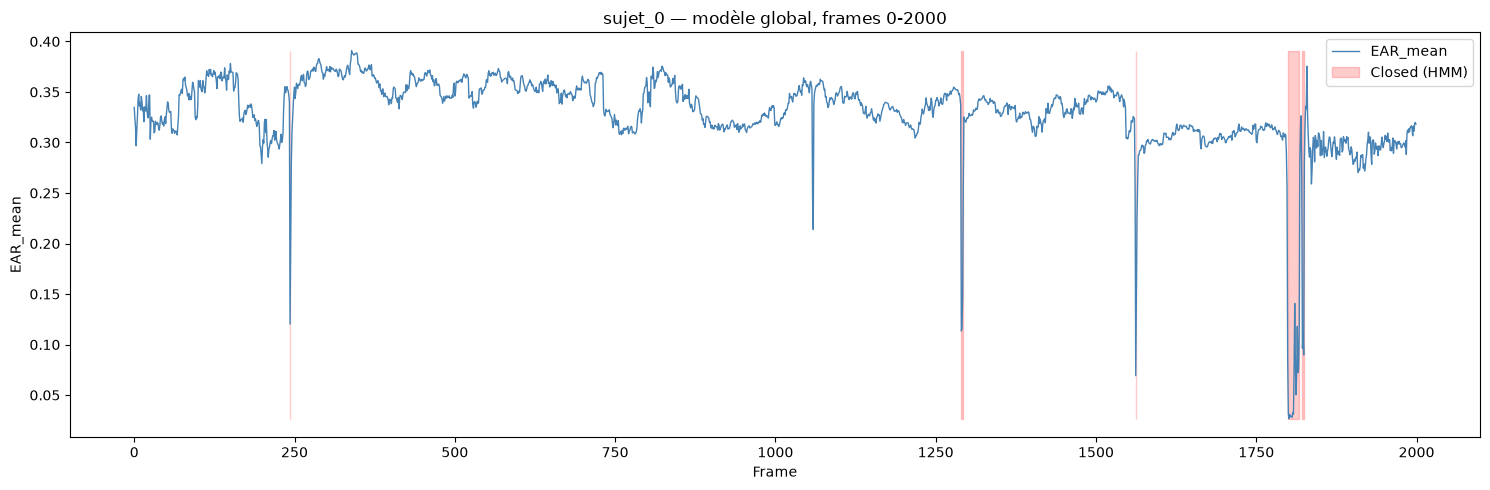

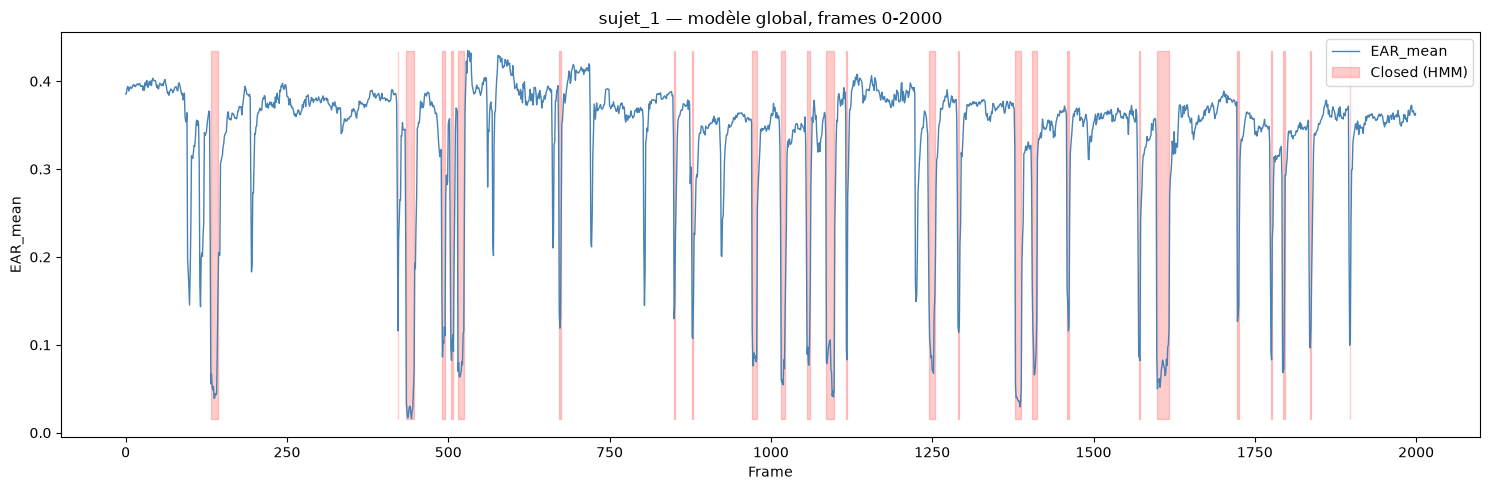

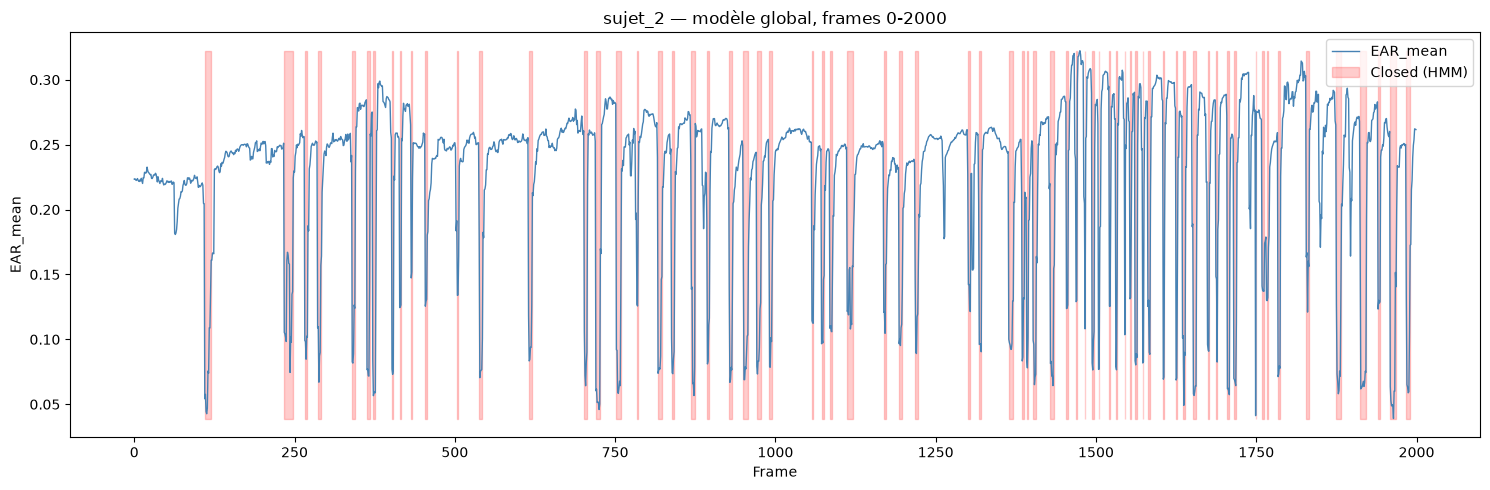

In [111]:
import matplotlib.pyplot as plt

X_all = np.concatenate([X_ear_mean_0, X_ear_mean_1, X_ear_mean_2])
lengths = [len(X_ear_mean_0), len(X_ear_mean_1), len(X_ear_mean_2)]

global_model = hmm.GaussianHMM(n_components=10, covariance_type="diag", n_iter=200, random_state=42)
global_model.fit(X_all, lengths=lengths)
closed_state_global = np.argmin(global_model.means_.flatten())
print(f"Closed state global: {closed_state_global}, means: {global_model.means_.flatten()}")

for name, seq in sequences.items():
    hidden_states = global_model.predict(seq)
    n_frames = 2000
    ear_subset = seq.flatten()[:n_frames]
    is_closed_subset = (hidden_states[:n_frames] == closed_state_global)

    fig, ax1 = plt.subplots(figsize=(15, 5))
    ax1.plot(ear_subset, color='steelblue', linewidth=1, label='EAR_mean')
    ax1.fill_between(np.arange(n_frames), ear_subset.min(), ear_subset.max(),
                      where=is_closed_subset, color='red', alpha=0.2, label='Closed (HMM)')
    ax1.set_title(f"{name} — modèle global, frames 0-{n_frames}")
    ax1.set_xlabel('Frame'); ax1.set_ylabel('EAR_mean')
    ax1.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [112]:
for name, seq in sequences.items():
    hidden_states = global_model.predict(seq)
    is_closed = (hidden_states == closed_state_global)

    perclos = (np.sum(is_closed) / len(seq)) * 100
    transitions_to_closed = np.diff(is_closed.astype(int)) == 1
    n_blinks = np.sum(transitions_to_closed)

    print(f"--- {name} (modèle global) ---")
    print(f"Perclos: {perclos:.2f}%")
    if n_blinks > 0:
        print(f"Nombre de fermetures: {n_blinks}, une fermeture toutes les {(len(seq)/25)/n_blinks:.2f} secondes")
    else:
        print("Nombre de fermetures: 0")
    print()

--- sujet_0 (modèle global) ---
Perclos: 0.87%
Nombre de fermetures: 57, une fermeture toutes les 11.05 secondes

--- sujet_1 (modèle global) ---
Perclos: 5.85%
Nombre de fermetures: 220, une fermeture toutes les 3.98 secondes

--- sujet_2 (modèle global) ---
Perclos: 19.25%
Nombre de fermetures: 557, une fermeture toutes les 1.38 secondes



The HMM model works very nice to identify which frames are corresponding closed eyes and so we can extract the right number of closures and the true perclos.
Moreover, the results are found are based on a person that is in class 1 corresponding to a kss of 6-7.

### Extract statistical data

In order to create a more relevant dataset for RF, I will extract data from each instance and each sign, moreover I will replace EBR by a number_of_closures, same for MAR using a HMM unsupervised and calculate the PERCLOS according to the framed labeled closed by HMM. For each sign, I will extract mean, std, number_of_closures, etc

In order to train a HMM to identify open/close states for a new person we need to feed him all the concatenated values of all the videos we have. However because of morphologic and recording differences we have different scales for each video of the same caracteristics, so we need to normlize those measures for each video.

In [113]:
def min_max_scaler(data):
    signs = ["EAR_left_", "EAR_right_", "EAR_mean_", "MAR_","HOP_gd_","HOP_hb_"]
    
    for sign in signs:
        cols = [c for c in data.columns if c.startswith(sign)]
    
        # Application du scaling ligne par ligne sur l'ensemble de vos features
        data[cols] = data[cols].apply(lambda row: (row - row.min()) / (row.max() - row.min() + 1e-5), axis=1)
        
    return data

#data = min_max_scaler(data)
#data.head()

In [114]:
import numpy as np
import pandas as pd
import joblib
from hmmlearn import hmm
from sklearn.base import BaseEstimator, TransformerMixin
from tsfresh import extract_features
from tsfresh.feature_extraction import EfficientFCParameters
from tsfresh.utilities.dataframe_functions import impute

SIGNS = ["EAR_mean_", "MAR_", "HOP_gd_", "HOP_hb_"] # "EAR_left_", "EAR_right_", we just keep the mean of both since individually it can give non representating results 33 eye closures for one, 120 for the other
EAR_SIGNS = [ "EAR_mean_"] #"EAR_left_", "EAR_right_",]
MAR_SIGN = "MAR_"
N_TIMESTEPS = 875


def wide_to_long(df, signs=SIGNS, n_timesteps=N_TIMESTEPS):
    """Format large ({sign}{t}) -> format long (id, time, kind, value) pour tsfresh."""
    frames = []
    for sign in signs:
        cols = [f"{sign}{t}" for t in range(n_timesteps)]
        sub = df[cols].copy()
        sub.columns = range(n_timesteps)
        sub["id"] = df.index
        long_sign = sub.melt(id_vars="id", var_name="time", value_name="value")
        long_sign["kind"] = sign.rstrip("_")
        frames.append(long_sign)
    return pd.concat(frames, ignore_index=True)


class HMMTrainer(BaseEstimator, TransformerMixin):
    """Entraîne un HMM par signe. means_/covars_ appris librement (nécessaire au-delà de 2 états)."""

    def __init__(self, n_components=10, n_iter=200, random_state=42,load=False):
        self.n_components = n_components
        self.n_iter = n_iter
        self.random_state = random_state
        self._load = load

    def fit(self, X, y=None):
        self.models_ = self._train_all(X) if not self._load else joblib.load("ML_Models/hmm_models.pkl")
        return self

    def transform(self, X):
        return {"data": X, "models": self.models_}

    def _train_all(self, X):
        models = {}
        for sign in SIGNS:
            cols = [f"{sign}{t}" for t in range(N_TIMESTEPS)]
            sequences = X[cols].to_numpy()

            X_sign = sequences.flatten().reshape(-1, 1)
            lengths = [sequences.shape[1]] * sequences.shape[0]

            model = hmm.GaussianHMM(
                n_components=self.n_components,
                covariance_type="diag",
                n_iter=self.n_iter,
                random_state=self.random_state,
            )
            model.fit(X_sign, lengths=lengths)
            models[sign] = model

        joblib.dump(models, "ML_Models/hmm_models.pkl")
        return models


class HMMFeatureComputer(BaseEstimator, TransformerMixin):
    """
    Features dérivées des états HMM uniquement : perclos, fermetures des yeux,
    durée moyenne/std des fermetures, bâillements. Les stats génériques
    (mean/median/std) sont laissées à tsfresh pour éviter la redondance.
    """

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return self._compute(X["data"], X["models"])

    def _compute(self, data, models):
        features = pd.DataFrame(index=data.index)

        for sign in EAR_SIGNS:
            cols = [f"{sign}{t}" for t in range(N_TIMESTEPS)]
            sign_values = data[cols].to_numpy()
            model = models[sign]
            closed_state = np.argmin(model.means_.flatten())

            eye_closures, perclos, mean_dur, std_dur = [], [], [], []

            for instance in sign_values:
                states = model.predict(instance.reshape(-1, 1))
                is_closed = states == closed_state # List of bool

                n_blinks = np.sum(np.diff(is_closed.astype(int)) == 1) # if we go from False to True -> 1-0 else if we go from True to False  -> 0-1 = -1 else 0 
                n_closed = np.sum(is_closed)

                closed_runs, current_run = [], 0
                for s in is_closed:
                    if s:
                        current_run += 1
                    elif current_run > 0:
                        closed_runs.append(current_run)
                        current_run = 0
                if current_run > 0:
                    closed_runs.append(current_run)

                eye_closures.append(n_blinks)
                perclos.append(n_closed / N_TIMESTEPS * 100)
                mean_dur.append(np.mean(closed_runs) if closed_runs else 0)
                std_dur.append(np.std(closed_runs) if closed_runs else 0)

            features[f"{sign}eye_closures"] = eye_closures
            features[f"{sign}perclos"] = perclos
            features[f"{sign}mean_closure_duration"] = mean_dur
            features[f"{sign}std_closure_duration"] = std_dur

        # MAR : bâillements (état "ouvert" = moyenne la plus haute)
        cols = [f"{MAR_SIGN}{t}" for t in range(N_TIMESTEPS)]
        sign_values = data[cols].to_numpy()
        model = models[MAR_SIGN]
        open_state = np.argmax(model.means_.flatten())

        yawns = []
        for instance in sign_values:
            states = model.predict(instance.reshape(-1, 1))
            is_open = states == open_state
            yawns.append(np.sum(np.diff(is_open.astype(int)) == 1))

        features[f"{MAR_SIGN}yawns"] = yawns
        return features

In [115]:
from sklearn.pipeline import Pipeline, FunctionTransformer

# 1. Features dérivées du HMM (perclos, fermetures, bâillements)
hmm_pipeline = Pipeline([
    ("Min_max_Scaler", FunctionTransformer(min_max_scaler)),
    ("Train_HMM", HMMTrainer(n_components=10, n_iter=50,load=True)),
    ("HMM_features", HMMFeatureComputer()),
])
hmm_features = hmm_pipeline.fit_transform(data)

# 2. Features génériques automatiques (tsfresh)
long_data = wide_to_long(data)
tsfresh_features = extract_features(
    long_data,
    column_id="id", column_sort="time", column_kind="kind", column_value="value",
    default_fc_parameters=EfficientFCParameters(),
    n_jobs=4,
    disable_progressbar=False,
)
impute(tsfresh_features)

# 3. Fusion — un seul dataframe, video_name/class attachés une seule fois
processed_data = pd.concat([hmm_features, tsfresh_features], axis=1)
processed_data["video_name"] = data["video_name"].values
processed_data["class"] = data["class"].values

Feature Extraction: 100%|██████████| 20/20 [02:38<00:00,  7.92s/it]
/home/sebastian/Documents/GitHub_Pro/Projet-Industriel-Capgemini/.venv/lib/python3.14/site-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning: The columns ['EAR_mean__query_similarity_count__query_None__threshold_0.0'
 'HOP_gd__query_similarity_count__query_None__threshold_0.0'
 'HOP_hb__query_similarity_count__query_None__threshold_0.0'
 'MAR__query_similarity_count__query_None__threshold_0.0'] did not have any finite values. Filling with zeros.
  warnings.warn(


In [116]:
processed_data.head()
processed_data.to_csv('csv/data_for_RF.scv')

Let's see if our HMM model works well on random dat

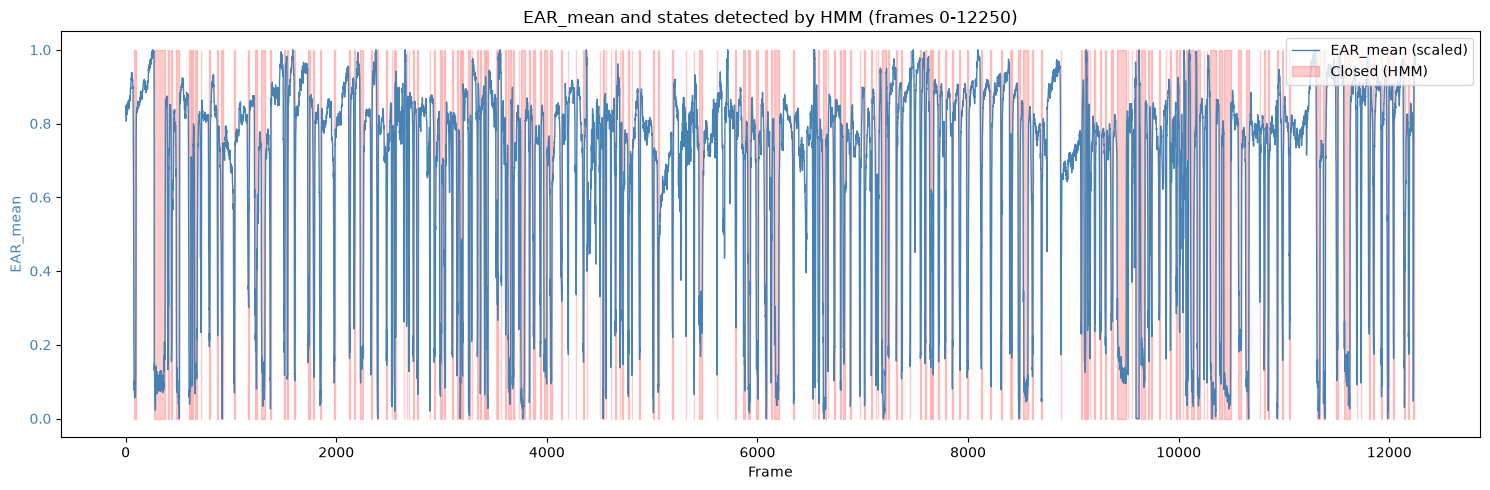

In [117]:
import joblib
import numpy as np
import matplotlib.pyplot as plt

hmm_model = joblib.load("ML_Models/hmm_models.pkl")
model = hmm_model["EAR_mean_"]

# Data à tester
X = data[data["video_name"] == "kss#8-9#F#rldd#12-10.mp4"]
ear_mean_cols = [c for c in X.columns if c.startswith("EAR_mean_")]

X_ear = X[ear_mean_cols].copy()

# Min-max par ligne (par instance), même formule que min_max_scaler
X_ear_scaled = X_ear.apply(
    lambda row: (row - row.min()) / (row.max() - row.min() + 1e-5), axis=1
)

X_ear_mean = X_ear_scaled.values.flatten().reshape(-1, 1)

# Predictions des états cachés
hidden_states = model.predict(X_ear_mean)

n_frames = X_ear_mean.shape[0]
ear_subset = X_ear_mean.flatten()[:n_frames]
states_subset = hidden_states[:n_frames]

closed_state = np.argmin(model.means_.flatten())

is_closed_subset = (states_subset == closed_state)

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(ear_subset, color='steelblue', linewidth=1, label='EAR_mean (scaled)')
ax1.set_xlabel('Frame')
ax1.set_ylabel('EAR_mean', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.fill_between(
    np.arange(n_frames),
    ear_subset.min(), ear_subset.max(),
    where=is_closed_subset,
    color='red', alpha=0.2, label='Closed (HMM)'
)
ax1.set_title(f"EAR_mean and states detected by HMM (frames 0-{n_frames})")
ax1.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Explorative Data Analysis

We need to take a look to the data in order to verify that our HMM models and new features are relevant and meaningfull.

We can see that even with some outliers, most of data tends to what was expected such as the EAR which is lower with the higher drowsiness.

## Splitting data

We avoid data leakage by being sure that no part of any video is in the two sets and we try to respect the imbalance in classes.

In [118]:
from sklearn.model_selection import train_test_split
from tsfresh import select_features

# Split par vidéo AVANT toute sélection (sinon fuite de données : select_features
# regarderait la relation feature <-> classe sur des vidéos qui finiraient dans le test)
videos = processed_data["video_name"].unique()

train_videos, test_videos = train_test_split(videos, test_size=0.20, random_state=42)

train_data = processed_data[processed_data["video_name"].isin(train_videos)]
test_data = processed_data[processed_data["video_name"].isin(test_videos)]

X_train = train_data.drop(columns=["class", "video_name"])
y_train = train_data["class"]
X_test = test_data.drop(columns=["class", "video_name"])
y_test = test_data["class"]

# Sélection statistique des features pertinentes — UNIQUEMENT sur le train
X_train_selected = select_features(X_train, y_train, multiclass=True, n_significant=1)

# On applique les mêmes colonnes retenues au test (jamais de select_features sur le test)
X_test_selected = X_test[X_train_selected.columns]

print(f"Features avant sélection : {X_train.shape[1]}")
print(f"Features après sélection : {X_train_selected.shape[1]}")

print(f"Instances train/test: {X_train_selected.shape[0]}/{X_test_selected.shape[0]}")

print(f"Imbalance class 0 train/test: {len(train_data[train_data['class']==0])/train_data.shape[0]:.2%}/{len(test_data[test_data['class']==0])/test_data.shape[0]:.2%}")
print(f"Imbalance class 1 train/test: {len(train_data[train_data['class']==1])/train_data.shape[0]:.2%}/{len(test_data[test_data['class']==1])/test_data.shape[0]:.2%}")
print(f"Imbalance class 2 train/test: {len(train_data[train_data['class']==2])/train_data.shape[0]:.2%}/{len(test_data[test_data['class']==2])/test_data.shape[0]:.2%}")

Features avant sélection : 3113
Features après sélection : 428
Instances train/test: 963/269
Imbalance class 0 train/test: 38.42%/31.60%
Imbalance class 1 train/test: 29.80%/26.77%
Imbalance class 2 train/test: 31.78%/41.64%


## Training a RF

In order to find the best estimator we'll use a randomsearch completed by Cross Validation so we don't need any validation set.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestClassifier

groups_video = train_data["video_name"]   # toujours depuis train_data, pas X_train_selected
y = y_train                                # déjà défini plus haut (= train_data["class"])
X = X_train_selected                       # features après sélection tsfresh

y_test = y_test                            # déjà défini plus haut (= test_data["class"])
X_test = X_test                  # mêmes colonnes que X, appliquées au test

param_dist = {
    "n_estimators": randint(10, 500),
    "max_features": randint(5, X.shape[1] + 1),
    "max_depth": randint(3, 30),
}

cv_strategy = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=100,
    cv=cv_strategy.split(X, y, groups=groups_video),
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X, y)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....x7c7fcc1be4c0>, 'max_features': <scipy.stats....x7c7f46e4b950>, 'n_estimators': <scipy.stats....x7c7ef8b58110>}"
,n_iter,100
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,<generator ob...x7c7fc4111360>
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [127]:
print("Best CV score  (f1_weighted):", search.best_score_)

Best CV score  (f1_weighted): 0.4472626964489316


## Evaluation of the best model

In [121]:
best_model = search.best_estimator_   # déjà entraîné sur X, y avec les meilleurs hyperparamètres

y_pred = best_model.predict(X_test)   # attention : X_test, pas test_data brut

First let's take a look to the confusion matrix

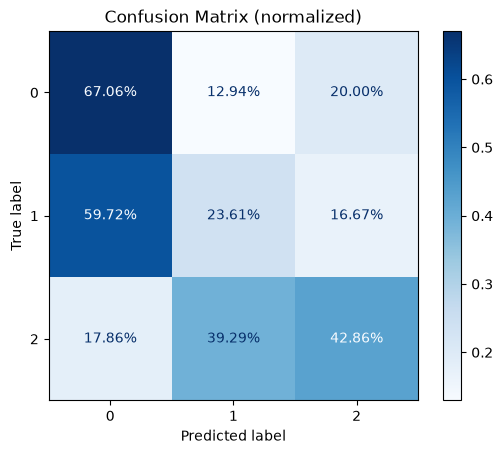

In [128]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize='true', cmap='Blues', values_format='.2%')
plt.title("Confusion Matrix (normalized)")
plt.show()

According to the confusion matrix, class 1 is misclassified into class 0 and some of class 2 instances are classified as class 1.

In [131]:
from sklearn.metrics import f1_score

f1_macro = f1_score(y_test, y_pred, average='macro')      # normal mean by classes in set
f1_weighted = f1_score(y_test, y_pred, average='weighted') # weighted by instances in set

print(f"F1 macro: {f1_macro:.3f}")
print(f"F1 weighted: {f1_weighted:.3f}")

F1 macro: 0.433
F1 weighted: 0.450


## Improvements

There are several axes I want to explore to understand the current performance
ceiling and how to improve the model's predictions:

1. **Leaking instances**: I will leak the instances coming from the same video into 

1. **Features importances on the whole dataset**: I will train my RF and see which
   features are the most relvant ones.

2. **Supervised dimensionality reduction (LDA)**: given the confusion matrix shows
   overlap concentrated between adjacent classes (0↔1, 1↔2) rather than random
   confusion, use LDA (not PCA, which is unsupervised and not designed to maximize
   class separability) to check whether the classes are genuinely close in feature
   space — this would help distinguish a data/task limitation from a model
   limitation.

### Using all the features

In [ ]:
# Split par vidéo AVANT toute sélection (sinon fuite de données : select_features
# regarderait la relation feature <-> classe sur des vidéos qui finiraient dans le test)
videos = processed_data["video_name"].unique()

train_videos, test_videos = train_test_split(videos, test_size=0.20, random_state=42)

train_data = processed_data[processed_data["video_name"].isin(train_videos)]
test_data = processed_data[processed_data["video_name"].isin(test_videos)]

X_train = train_data.drop(columns=["class", "video_name"])
y_train = train_data["class"]
X_test = test_data.drop(columns=["class", "video_name"])
y_test = test_data["class"]


print(f"Instances train/test: {X_train.shape[0]}/{X_test.shape[0]}")

print(f"Imbalance class 0 train/test: {len(train_data[train_data['class']==0])/train_data.shape[0]:.2%}/{len(test_data[test_data['class']==0])/test_data.shape[0]:.2%}")
print(f"Imbalance class 1 train/test: {len(train_data[train_data['class']==1])/train_data.shape[0]:.2%}/{len(test_data[test_data['class']==1])/test_data.shape[0]:.2%}")
print(f"Imbalance class 2 train/test: {len(train_data[train_data['class']==2])/train_data.shape[0]:.2%}/{len(test_data[test_data['class']==2])/test_data.shape[0]:.2%}")

Instances train/test: 963/269
Imbalance class 0 train/test: 38.42%/31.60%
Imbalance class 1 train/test: 29.80%/26.77%
Imbalance class 2 train/test: 31.78%/41.64%


In [134]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestClassifier

groups_video = train_data["video_name"]  
y = y_train                                
X = X_train                     


param_dist = {
    "n_estimators": randint(10, 1000),
    "max_features": randint(5, X.shape[1] + 1),
    "max_depth": randint(3, 30),
}

cv_strategy = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=10,
    cv=cv_strategy.split(X, y, groups=groups_video),
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X, y)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....x7c7ef8c49250>, 'max_features': <scipy.stats....x7c7ef8c490d0>, 'n_estimators': <scipy.stats....x7c7f455bf6e0>}"
,n_iter,10
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,<generator ob...x7c7f6b39f520>
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [135]:
print("Best CV score  (f1_weighted):", search.best_score_)

Best CV score  (f1_weighted): 0.4334033016737478


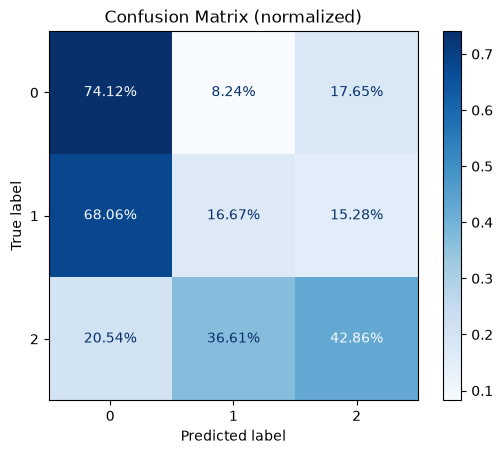

In [136]:
best_model = search.best_estimator_   # déjà entraîné sur X, y avec les meilleurs hyperparamètres

y_pred = best_model.predict(X_test)   # attention : X_test, pas test_data brut

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize='true', cmap='Blues', values_format='.2%')
plt.title("Confusion Matrix (normalized)")
plt.show()

In [149]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

# Trier et prendre les 100 plus importantes
feature_importance.sort_values(ascending=False).head(100)



EAR_mean__agg_linear_trend__attr_"stderr"__chunk_len_5__f_agg_"max"     0.025371
EAR_mean_std_closure_duration                                           0.020436
EAR_mean__agg_linear_trend__attr_"stderr"__chunk_len_10__f_agg_"max"    0.012517
EAR_mean_mean_closure_duration                                          0.009152
EAR_mean__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.2    0.007352
                                                                          ...   
EAR_mean__fft_coefficient__attr_"abs"__coeff_20                         0.000793
HOP_gd__energy_ratio_by_chunks__num_segments_10__segment_focus_5        0.000793
HOP_gd__fft_coefficient__attr_"angle"__coeff_38                         0.000790
EAR_mean__fourier_entropy__bins_5                                       0.000788
HOP_hb__fft_coefficient__attr_"angle"__coeff_90                         0.000788
Length: 100, dtype: float64

In [148]:
# Importances individuelles
importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

# Extraire le préfixe
prefix_importance = importance.groupby(
    importance.index.str.split("_").str[0]
).sum()

# Trier
prefix_importance = prefix_importance.sort_values(ascending=False)

print(prefix_importance)

EAR    0.416568
HOP    0.388694
MAR    0.194739
dtype: float64


### LDA

Variance expliquée par composante : [0.57513584 0.42486416]


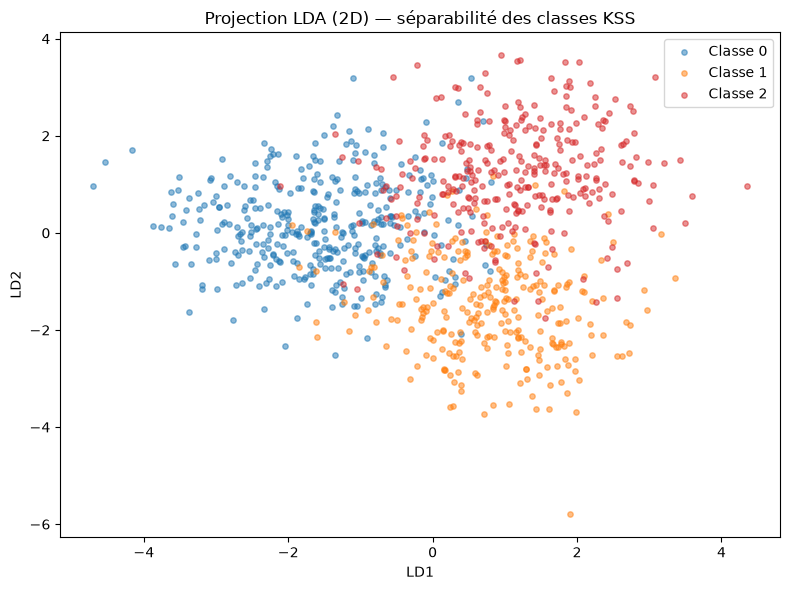

In [150]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X = X_train_selected
y = y_train

# Avec 3 classes, LDA peut extraire au maximum (n_classes - 1) = 2 composantes
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

print("Variance expliquée par composante :", lda.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 6))
colors = {0: "tab:blue", 1: "tab:orange", 2: "tab:red"}

for cls in sorted(y.unique()):
    mask = y == cls
    ax.scatter(
        X_lda[mask, 0], X_lda[mask, 1],
        label=f"Classe {cls}", alpha=0.5, s=15, color=colors[cls]
    )

ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.set_title("Projection LDA (2D) — séparabilité des classes KSS")
ax.legend()
plt.tight_layout()
plt.show()

Here we can see that class 1 is melting in class 0 and 2 explaining why the models struggles to identify it and generalize to the probelem.